In [ ]:
# Cell 1 - Mount Drive
from google.colab import drive

try:
    drive.mount('/content/drive')
    print('✅ Drive mounted!')
except:
    print('✅ Drive already mounted!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!


In [ ]:
# Cell 2 - Check datasets available
import pandas as pd
import os

base = '/content/drive/MyDrive/PhishingDetector/dataset'

print('📁 Files available:')
print(os.listdir(base))

📁 Files available:
['Ling.csv', 'Enron.csv', 'CEAS_08.csv', 'Nazario.csv', 'Nigerian_Fraud.csv', 'SpamAssasin.csv', 'phishing_email.csv']


In [ ]:
# Cell 3 - Merge best datasets
import pandas as pd

base = '/content/drive/MyDrive/PhishingDetector/dataset'
dfs = []

# CEAS_08 - real spam competition dataset
df1 = pd.read_csv(f'{base}/CEAS_08.csv')
df1['text'] = df1['subject'].fillna('') + ' ' + df1['body'].fillna('')
df1 = df1[['text', 'label']]
dfs.append(df1)
print(f'✅ CEAS_08: {len(df1)} rows')

# Enron - corporate emails
df2 = pd.read_csv(f'{base}/Enron.csv')
df2['text'] = df2['subject'].fillna('') + ' ' + df2['body'].fillna('')
df2 = df2[['text', 'label']]
dfs.append(df2)
print(f'✅ Enron: {len(df2)} rows')

# Nazario - real phishing emails
df3 = pd.read_csv(f'{base}/Nazario.csv')
df3['text'] = df3['subject'].fillna('') + ' ' + df3['body'].fillna('')
df3 = df3[['text', 'label']]
dfs.append(df3)
print(f'✅ Nazario: {len(df3)} rows')

# Nigerian Fraud - classic phishing
df4 = pd.read_csv(f'{base}/Nigerian_Fraud.csv')
df4['text'] = df4['subject'].fillna('') + ' ' + df4['body'].fillna('')
df4 = df4[['text', 'label']]
dfs.append(df4)
print(f'✅ Nigerian_Fraud: {len(df4)} rows')

# SpamAssasin - benchmark dataset
df5 = pd.read_csv(f'{base}/SpamAssasin.csv')
df5['text'] = df5['subject'].fillna('') + ' ' + df5['body'].fillna('')
df5 = df5[['text', 'label']]
dfs.append(df5)
print(f'✅ SpamAssasin: {len(df5)} rows')

# Merge all
merged = pd.concat(dfs, ignore_index=True)
merged = merged.dropna()
merged = merged.drop_duplicates()
merged = merged.reset_index(drop=True)

print(f'\n📊 Merged shape: {merged.shape}')
print(f'📊 Label distribution:')
print(merged['label'].value_counts())

✅ CEAS_08: 39154 rows
✅ Enron: 29767 rows
✅ Nazario: 1565 rows
✅ Nigerian_Fraud: 3332 rows
✅ SpamAssasin: 5809 rows

📊 Merged shape: (79627, 2)
📊 Label distribution:
label
1    42433
0    37194
Name: count, dtype: int64


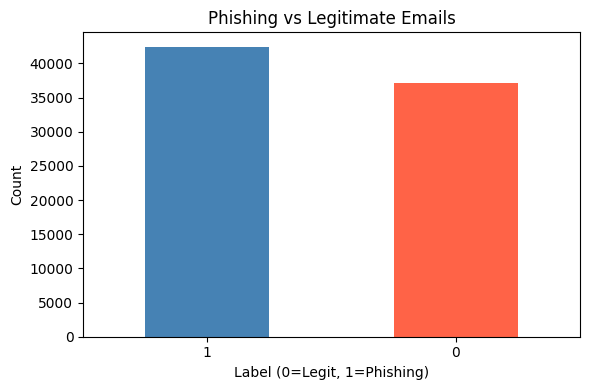

✅ Plot saved!

🔍 Sample phishing email:
Never agree to be a loser Buck up, your troubles caused by small dimension will soon be over!
Become a lover no woman will be able to resist!
http://whitedone.com/


come. Even as Nazi tanks were rolling down the streets, the dreamersphilosopher or a journalist. He was still not sure.I do the same.

🔍 Sample legit email:
Re: svn commit: r619753 - in /spamassassin/trunk: lib/Mail/SpamAssassin/PerMsgStatus.pm lib/Mail/SpamAssassin/Util/RegistrarBoundaries.pm t/uri_text.t Would anyone object to removing .so from this list?  The .so TLD is  
basically dead and we've found that lots of bogus domains like lib*.so  
are be


In [ ]:
# Cell 4 - Explore merged data
import matplotlib.pyplot as plt
import os

os.makedirs('/content/drive/MyDrive/PhishingDetector/plots', exist_ok=True)

# Class distribution plot
plt.figure(figsize=(6,4))
merged['label'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Phishing vs Legitimate Emails')
plt.xlabel('Label (0=Legit, 1=Phishing)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()

save_path = '/content/drive/MyDrive/PhishingDetector/plots/class_distribution.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Plot saved!')
print(f'\n🔍 Sample phishing email:')
print(merged[merged['label']==1]['text'].iloc[0][:300])
print(f'\n🔍 Sample legit email:')
print(merged[merged['label']==0]['text'].iloc[0][:300])

In [ ]:
# Cell 5 - Save merged raw data
import os

os.makedirs('/content/drive/MyDrive/PhishingDetector/data/raw', exist_ok=True)

save_path = '/content/drive/MyDrive/PhishingDetector/data/raw/merged_raw.csv'
merged.to_csv(save_path, index=False)

if os.path.exists(save_path):
    size = round(os.path.getsize(save_path) / (1024*1024), 2)
    print(f'✅ Merged raw data saved!')
    print(f'💾 Size: {size} MB')
    print(f'📊 Total rows: {len(merged)}')

✅ Merged raw data saved!
💾 Size: 133.2 MB
📊 Total rows: 79627
